<img src="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/imgs/banner_fcd.jpg?raw=1" alt="bannersp" width="1100"  height="150">

## <span style="color:#2F749F;"><strong>📦 Sesión práctica 5: Imputación de datos</strong></span>
---
<p align="right">
  <a href="https://colab.research.google.com/github/Veritax0/BEV-vs-ICE/blob/main/sesiones_practicas/sp_5_Juan_Manuel_Vera.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>

## <span style="color:#2F749F;"><strong>Ejercicio 1. Limpieza e imputación de un conjunto de datos mixto</strong></span>

1. Crea el DataFrame base **df** ejecutando el siguiente código:
    ```python
    df = pd.DataFrame({
        'Nombre': ['Ana', 'Luis', 'Pedro', None, 'Marta', 'Luis', 'Sofía'],
        'Edad': [25, np.nan, 35, 29, -5, 25, None],
        'Ciudad': ['Bogotá', 'Medellín', None, 'Medellín', 'Cali', 'Bogotá', 'Cali'],
        'Ingreso': [3500, 4800, np.nan, 5200, 5100, np.nan, 4700],
        'FechaIngreso': ['2023-01-01', '2023-01-05', None, '2023-01-10', '2023-01-12', None, '2023-01-15']
    })

2. En un nuevo notebook, aplica las etapas del proceso de limpieza e imputación de datos que consideres necesarias sobre el DataFrame df. Ten encuenta incluir:
    - Código correctamente comentado y ejecutado.
    - Explicaciones breves de cada paso.
    - Resultados visuales o estadísticos que evidencien las transformaciones.

In [25]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression


df = pd.DataFrame({
    'Nombre': ['Ana', 'Luis', 'Pedro', None, 'Marta', 'Luis', 'Sofía'],
    'Edad': [25, np.nan, 35, 29, -5, 25, None],
    'Ciudad': ['Bogotá', 'Medellín', None, 'Medellín', 'Cali', 'Bogotá', 'Cali'],
    'Ingreso': [3500, 4800, np.nan, 5200, 5100, np.nan, 4700],
    'FechaIngreso': ['2023-01-01', '2023-01-05', None, '2023-01-10', '2023-01-12', None, '2023-01-15']
})

In [ ]:
df

,Nombre,Edad,Ciudad,Ingreso,FechaIngreso
0,Ana,25.0,Bogotá,3500.0,2023-01-01
1,Luis,NaN,Medellín,4800.0,2023-01-05
2,Pedro,35.0,None,NaN,None
3,None,29.0,Medellín,5200.0,2023-01-10
4,Marta,-5.0,Cali,5100.0,2023-01-12
5,Luis,25.0,Bogotá,NaN,None
6,Sofía,NaN,Cali,4700.0,2023-01-15


In [ ]:
df.isnull().sum()

,0
Nombre,1
Edad,2
Ciudad,1
Ingreso,2
FechaIngreso,2


A primera vista se pueden evidenciar varios valores faltantes, en un principio no hay ningun registro o columna que sea candito a eliminación por una alta cantidad de datos faltantes, el unico que podría considerarse es el registro número dos que unicamente tiene un nombre y una edad, sin embargo las variables númericas podrían ser imputadas

In [ ]:
df[df.duplicated()]

,Nombre,Edad,Ciudad,Ingreso,FechaIngreso


No se observan registros duplicados, por lo que pasamos a normalizar las variables de tipo texto para eliminar mayúsculas y carácteres especiales, especificamente sobre las variables de Nombre y Ciudad

Para facilitar este proceso, primero imputamos los valores faltantes de cada vairable, en el caso del nombre podemos reemplazar los valores faltantes con "Desconocido", para el caso de la ciudad, los valores faltantes se reemplaza tambien con "Desconocido", debido a que no hay una moda clara en la variable, varias ciudades aparecen el mismo número de veces

In [ ]:
df['Ciudad'].mode()

,Ciudad
0,Bogotá
1,Cali
2,Medellín


In [ ]:
df['Nombre'] = df['Nombre'].fillna('Desconocido')
df['Ciudad'] = df['Ciudad'].fillna('Desconocido')

Ahora si eliminamos mayúsculas y carácteres especiales

In [ ]:
def quitar_tildes(cadena):
    # Convierte a Unicode y descompone los caracteres (NFD)
    s = unicodedata.normalize('NFD', cadena)
    # Filtra y mantiene solo caracteres que no sean de diéresis/tilde (Mn: Mark Nonspacing)
    return ''.join(c for c in s if unicodedata.category(c) != 'Mn')

In [ ]:
import unicodedata
df['Ciudad'] = df['Ciudad'].apply(str.strip).apply(str.lower).apply(str.lstrip).apply(quitar_tildes)
df['Nombre'] = df['Nombre'].apply(str.strip).apply(str.lower).apply(str.lstrip).apply(quitar_tildes)

Revisamos y tratamos los datos atipicos que podamos encontrar en las variables de Edad, Ingreso y fechaIngreso, observando los datos se puede identificar que el unico dato atipico es una edad de -5, que podría corresponder a un error de registro.

Imputamos la variable edad para los valores faltantes y el valor atípico detectado, como tenemos un valor negativo, primero reemplazamos este valor con un valor vacio para que no afecte la media, luego imputamos con este metodo para mantener la distribución

In [ ]:
df['Edad'] = df['Edad'].replace(-5, np.nan)
df['Edad'] = df['Edad'].fillna(df['Edad'].mean())

Continuamos con la variable Ingreso, esta la podemos imputar directamente con la media, pues solo tiene 2 valores faltantes y no es necesario reemplazar ningun atipico antes de realizar la imputación

In [ ]:
df['Ingreso'] = df['Ingreso'].fillna(df['Ingreso'].mean())

Finalmente imputamos la columna de FechaIngreso, debido a que es una fecha que puede afectar la interpretación de los datos, reemplazamos los valores faltantes con una fecha generica, luego normalizamos el formato de las fechas, para esta usamos el metodo pd.to_datetime(), que nos permite normalizar las fechas existentes a formato ISO

In [ ]:
df['FechaIngreso'] = df['FechaIngreso'].fillna(pd.to_datetime('1900-01-01'))
df['FechaIngreso'] = pd.to_datetime(df['FechaIngreso'], errors='coerce')

In [ ]:
df

,Nombre,Edad,Ciudad,Ingreso,FechaIngreso
0,ana,25.0,bogota,3500.0,2023-01-01
1,luis,28.5,medellin,4800.0,2023-01-05
2,pedro,35.0,desconocido,4660.0,1900-01-01
3,desconocido,29.0,medellin,5200.0,2023-01-10
4,marta,28.5,cali,5100.0,2023-01-12
5,luis,25.0,bogota,4660.0,1900-01-01
6,sofia,28.5,cali,4700.0,2023-01-15


Podemos observar que logramos tratar todos los datos faltantes de la muestra, sin afectar a nivel general la distribución que tenian los datos originales

## <span style="color:#2F749F;"><strong>Ejercicio 2. Limpieza de duplicados</strong></span>

1. Crea el DataFrame base **df** ejecutando el siguiente código:
    ```python
    df = pd.DataFrame({
        'ID': [101, 102, 102, 103, 104, 104, 104],
        'Nombre': ['Ana', 'Luis', 'Luis', 'Marta', 'Carlos', 'Carlos', 'Carlos'],
        'Edad': [25, 30, 30, 29, 40, 40, 41],
        'Ciudad': ['Bogotá', 'Cali', 'Cali', 'Medellín', 'Cali', 'Cali', 'Cali'],
        'FechaRegistro': ['2023-01-01', '2023-01-05', '2023-01-05', '2023-01-10',
                        '2023-01-15', '2023-01-15', '2023-01-16']
    })

2.  En el mismo notebook anterior, para el nuevo dataframe df, responde a las siguientes preguntas (utilizando python):
    - ¿Cuál es el total de registros originales?
    - ¿Cuáles y cuántos son los duplicados exactos?
    - ¿Cuáles y cuántos son los duplicados por varias columnas?
    - ¿Cuántos registros debes eliminar?
    - ¿Cuántos registros quedan después de la limpieza?

In [ ]:
df = pd.DataFrame({
    'ID': [101, 102, 102, 103, 104, 104, 104],
    'Nombre': ['Ana', 'Luis', 'Luis', 'Marta', 'Carlos', 'Carlos', 'Carlos'],
    'Edad': [25, 30, 30, 29, 40, 40, 41],
    'Ciudad': ['Bogotá', 'Cali', 'Cali', 'Medellín', 'Cali', 'Cali', 'Cali'],
    'FechaRegistro': ['2023-01-01', '2023-01-05', '2023-01-05', '2023-01-10',
                    '2023-01-15', '2023-01-15', '2023-01-16']
})

En el siguiente resumen del dataframe, podemos observar que tenemos un total de 7 registros originales

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   ID             7 non-null      int64 
 1   Nombre         7 non-null      object
 2   Edad           7 non-null      int64 
 3   Ciudad         7 non-null      object
 4   FechaRegistro  7 non-null      object
dtypes: int64(2), object(3)
memory usage: 412.0+ bytes


In [ ]:
df.shape

(7, 5)

In [ ]:
df[df.duplicated()]

,ID,Nombre,Edad,Ciudad,FechaRegistro
2,102,Luis,30,Cali,2023-01-05
5,104,Carlos,40,Cali,2023-01-15


Podemos observar que si usamos el metodo duplicated con todas las columnas para determinar los duplicados exactos, el resultado es un datraframe con solo 2 registros, esto significa que estos dos registros 2 y 5 tienen duplicados identicos dentro del dataframe, para un total de 4 registros repeditos como se puede observar en la tabla original

In [ ]:
df

,ID,Nombre,Edad,Ciudad,FechaRegistro
0,101,Ana,25,Bogotá,2023-01-01
1,102,Luis,30,Cali,2023-01-05
2,102,Luis,30,Cali,2023-01-05
3,103,Marta,29,Medellín,2023-01-10
4,104,Carlos,40,Cali,2023-01-15
5,104,Carlos,40,Cali,2023-01-15
6,104,Carlos,41,Cali,2023-01-16


Además de los 4 registros duplicados, podemos observar que el ultimo registro tiene todos los valores identicos al registro anterior, exceptuando la edad y la fecha, tambien sería posible considerarlos como un duplicado por algunas columnas

En el siguiente metodo, podemos observar que si se buscan duplicados ignorando las variables de edad y fecha de registro, tomamos un registro adicional como duplicado, por lo que tenemos un registro con 2 copias y otro registro con 3, para un total de 5 duplicados si los consideramos por columnas

In [ ]:
df[df.duplicated(["ID","Nombre", "Ciudad"])]

,ID,Nombre,Edad,Ciudad,FechaRegistro
2,102,Luis,30,Cali,2023-01-05
5,104,Carlos,40,Cali,2023-01-15
6,104,Carlos,41,Cali,2023-01-16


Si eliminamos los registros duplicados, teniendo en cuenta que debemos dejar una de las copias, eliminariamos los registros 2, 5 y 6, quedando con un total de 4 registros restantes


## <span style="color:#2F749F;"><strong>Ejercicio 3. Corrección de errores tipográficos o de codificación</strong></span>


1. Crea el DataFrame base **df** ejecutando el siguiente código:
    ```python
    df = pd.DataFrame({
        'Ciudad': ['bogota', 'Bogotá', 'BOGOTA', 'bogotá', 'bogata', 'Bógota', 'BogoTa', 'Cali', 'calí', 'medellín', 'medellin']
    })

2.  En el mismo notebook anterior, para el nuevo dataframe df, estandariza la variable ciudad utilizando python.

In [ ]:
df = pd.DataFrame({
    'Ciudad': ['bogota', 'Bogotá', 'BOGOTA', 'bogotá', 'bogata', 'Bógota', 'BogoTa', 'Cali', 'calí', 'medellín', 'medellin']
})

In [ ]:
df

,Ciudad
0,bogota
1,Bogotá
2,BOGOTA
3,bogotá
4,bogata
5,Bógota
6,BogoTa
7,Cali
8,calí
9,medellín


In [ ]:
def quitar_tildes(cadena):
    # Convierte a Unicode y descompone los caracteres (NFD)
    s = unicodedata.normalize('NFD', cadena)
    # Filtra y mantiene solo caracteres que no sean de diéresis/tilde (Mn: Mark Nonspacing)
    return ''.join(c for c in s if unicodedata.category(c) != 'Mn')

In [ ]:
import unicodedata
df['Ciudad'] = df['Ciudad'].apply(str.strip).apply(str.lower).apply(str.lstrip).apply(quitar_tildes)

In [ ]:
df

,Ciudad
0,bogota
1,bogota
2,bogota
3,bogota
4,bogata
5,bogota
6,bogota
7,cali
8,cali
9,medellin


Con este código estamos convirtiendo toda la columna a string normalizado aplicando los siguientes metodos en orden, eliminar espacios, pasar todo a minuscula, y eliminar caracteres especiales como las tildes, esto nos permite tratarla como una variable categorica con la tranquilidad de que las clases estan estandarizadas

## <span style="color:#2F749F;"><strong>Ejercicio 4. Identificación de mecanismos de datos faltantes (MCAR, MAR, MNAR)</strong></span>
1. Se tiene una base de datos de estudiantes universitarios con las siguientes variables: , Edad, Género, Promedio académico, Ingreso familiar y Horas de estudio por semana. Sin embargo, hay valores faltantes en algunas variables.
2. En los siguientes escenarios, clasifica el tipo de dato faltante (MCAR, MAR o MNAR) y justifica tu respuesta en máximo 2 líneas.
   - **Escenario 1.**  Al analizar los datos, se observa que los valores faltantes en Ingreso familiar aparecen de forma completamente aleatoria, sin relación con ninguna otra variable (ni edad, ni género, ni promedio, etc.).
   - **Escenario 2.** Se detecta que los valores faltantes en Horas de estudio ocurren principalmente en estudiantes con promedios bajos.
   - **Escenario 3.** Se detecta que los valores faltantes en Horas de estudio ocurren principalmente en estudiantes con promedios bajos.
   - **Escenario 4.** Se observa que los valores faltantes en Promedio académico aparecen con mayor frecuencia en estudiantes de cierto género.
   - **Escenario 5.** Algunos estudiantes con muy pocas horas de estudio no reportan esta variable porque consideran que el valor es “demasiado bajo” para registrarlo.
   

1. MCAR, pues la probabilidad de que el ingreso familiar falte no se relaciona con otras variables.
2. MAR, en este caso, la probabilidad de que falte un valor en las Horas de estudio se ve relacionado con la variable de Promedio académico y podría explicarse a traves de esta.
3. Escenario repetido jaja.
4. MAR, nuevamente la probabilidad de que el promedio esté ausente depende de la variable género y podría imputarse a través de esta.
5. MNAR, En este caso cuando falta un valor de horas de estudio es porque el propio valor es bajo, por lo que depende de la misma variable

## <span style="color:#2F749F;"><strong>Ejercicio 5. Imputación con KNN y regresión</strong></span>

1. Crea el DataFrame base ejecutando el siguiente código:

    ```python
        import pandas as pd
        import numpy as np

        np.random.seed(42)

        n = 30

        df = pd.DataFrame({
            'Edad': np.random.randint(18, 60, n),
            'Promedio': np.round(np.random.uniform(2.0, 5.0, n), 2),
            'Horas_estudio': np.random.randint(0, 40, n),
            'Ingreso_familiar': np.random.randint(800000, 8000000, n),
            'Semestres_cursados': np.random.randint(1, 10, n)
        })

        # Introducción de valores faltantes con distintos patrones
        df.loc[[2, 5, 8, 15], 'Promedio'] = np.nan
        df.loc[[1, 7, 10, 18], 'Horas_estudio'] = np.nan
        df.loc[[3, 6, 14], 'Ingreso_familiar'] = np.nan

2. Al analizar el dataframe `df`:
   - ¿Qué variables tienen mayor proporción de datos faltantes?
   - ¿Observas algún patrón estructurado o parecen aleatorios?

3. Realiza la imputación de valores faltantes utilizando KNN y regresión
4. Analiza si se preserva la naturaleza de los datos con cada una de las técnicas de imputación (KNN y regresión)

In [26]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 30

df = pd.DataFrame({
    'Edad': np.random.randint(18, 60, n),
    'Promedio': np.round(np.random.uniform(2.0, 5.0, n), 2),
    'Horas_estudio': np.random.randint(0, 40, n),
    'Ingreso_familiar': np.random.randint(800000, 8000000, n),
    'Semestres_cursados': np.random.randint(1, 10, n)
})

    # Introducción de valores faltantes con distintos patrones
df.loc[[2, 5, 8, 15], 'Promedio'] = np.nan
df.loc[[1, 7, 10, 18], 'Horas_estudio'] = np.nan
df.loc[[3, 6, 14], 'Ingreso_familiar'] = np.nan

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Edad                30 non-null     int64  
 1   Promedio            26 non-null     float64
 2   Horas_estudio       26 non-null     float64
 3   Ingreso_familiar    27 non-null     float64
 4   Semestres_cursados  30 non-null     int64  
dtypes: float64(3), int64(2)
memory usage: 1.3 KB


In [28]:
df

,Edad,Promedio,Horas_estudio,Ingreso_familiar,Semestres_cursados
0,56,2.70,35.0,2909818.0,7
1,46,2.27,NaN,3031785.0,7
2,32,NaN,30.0,5283302.0,9
3,25,3.15,14.0,NaN,3
4,38,4.95,7.0,3525928.0,7
5,56,NaN,13.0,4653339.0,1
6,36,4.58,22.0,NaN,4
7,40,4.04,NaN,1879111.0,4
8,28,NaN,20.0,1796107.0,5
9,28,2.04,15.0,4321441.0,7


Revisando el dataframe se podrían construir algunas hipotesis según el comportamiento de los datos faltantes, por ejemplo, las horas de estudio faltantes parecieran estar relacionadas con edades más avanzadas, lo cual es congruente con menos tiempo disponible en el caso de las personas más adultas. En las otras dos variables no logro identificar ningún patron, quiza podríamos inferir que un promedio faltante se relaciona con un número bajo de horas de estudio, aunque no ocurre en todos los casos.

In [29]:

# Copia del dataframe
df_knn = df.copy()

# Inicializar imputador KNN
imputer_knn = KNNImputer(n_neighbors=3)

# Aplicar imputación
df_knn_imputed = pd.DataFrame(
    imputer_knn.fit_transform(df_knn),
    columns=df_knn.columns
)

# Redondear columnas que deben ser enteras
df_knn_imputed['Edad'] = df_knn_imputed['Edad'].round().astype(int)
df_knn_imputed['Horas_estudio'] = df_knn_imputed['Horas_estudio'].round().astype(int)
df_knn_imputed['Ingreso_familiar'] = df_knn_imputed['Ingreso_familiar'].round().astype(int)
df_knn_imputed['Semestres_cursados'] = df_knn_imputed['Semestres_cursados'].round().astype(int)

print("DataFrame imputado con KNN:")
print(df_knn_imputed)

DataFrame imputado con KNN:
    Edad  Promedio  Horas_estudio  Ingreso_familiar  Semestres_cursados
0     56  2.700000             35           2909818                   7
1     46  2.270000             21           3031785                   7
2     32  3.473333             30           5283302                   9
3     25  3.150000             14           2955269                   3
4     38  4.950000              7           3525928                   7
5     56  3.473333             13           4653339                   1
6     36  4.580000             22           3609593                   4
7     40  4.040000             21           1879111                   4
8     28  3.473333             20           1796107                   5
9     28  2.040000             15           4321441                   7
10    41  4.830000             21           7930144                   7
11    53  3.690000             23           5345583                   4
12    57  3.160000             25   

In [33]:

df_reg_simple = df.copy()

def imputar_con_edad(df, target):

    mask_missing = df[target].isnull()

    X_train = df.loc[~mask_missing, ["Edad"]]
    y_train = df.loc[~mask_missing, target]

    X_missing = df.loc[mask_missing, ["Edad"]]

    # Modelo
    reg = LinearRegression()
    reg.fit(X_train, y_train)

    # Imputación
    df.loc[mask_missing, target] = reg.predict(X_missing)

    return df

# Aplicar a columnas con NaN
for col in ["Promedio", "Horas_estudio", "Ingreso_familiar"]:
    df_reg_simple = imputar_con_edad(df_reg_simple, col)

# Ajustar tipos
df_reg_simple['Horas_estudio'] = df_reg_simple['Horas_estudio'].round().astype(int)
df_reg_simple['Ingreso_familiar'] = df_reg_simple['Ingreso_familiar'].round().astype(int)

print(df_reg_simple)

    Edad  Promedio  Horas_estudio  Ingreso_familiar  Semestres_cursados
0     56  2.700000             35           2909818                   7
1     46  2.270000             20           3031785                   7
2     32  3.317632             30           5283302                   9
3     25  3.150000             14           4645949                   3
4     38  4.950000              7           3525928                   7
5     56  3.494655             13           4653339                   1
6     36  4.580000             22           4439097                   4
7     40  4.040000             19           1879111                   4
8     28  3.288128             20           1796107                   5
9     28  2.040000             15           4321441                   7
10    41  4.830000             19           7930144                   7
11    53  3.690000             23           5345583                   4
12    57  3.160000             25           2670230             

In [31]:
# Función para graficar distribuciones
def graficar_distribuciones(df, titulo):
    df.hist(bins=10, figsize=(12, 8))
    plt.suptitle(titulo)
    plt.show()

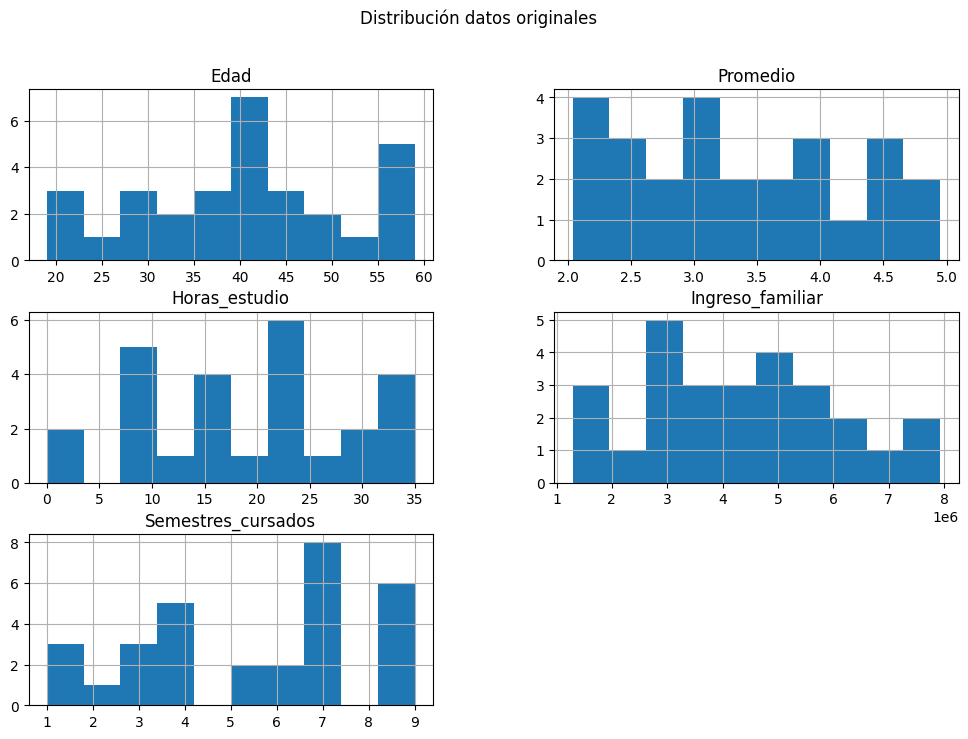

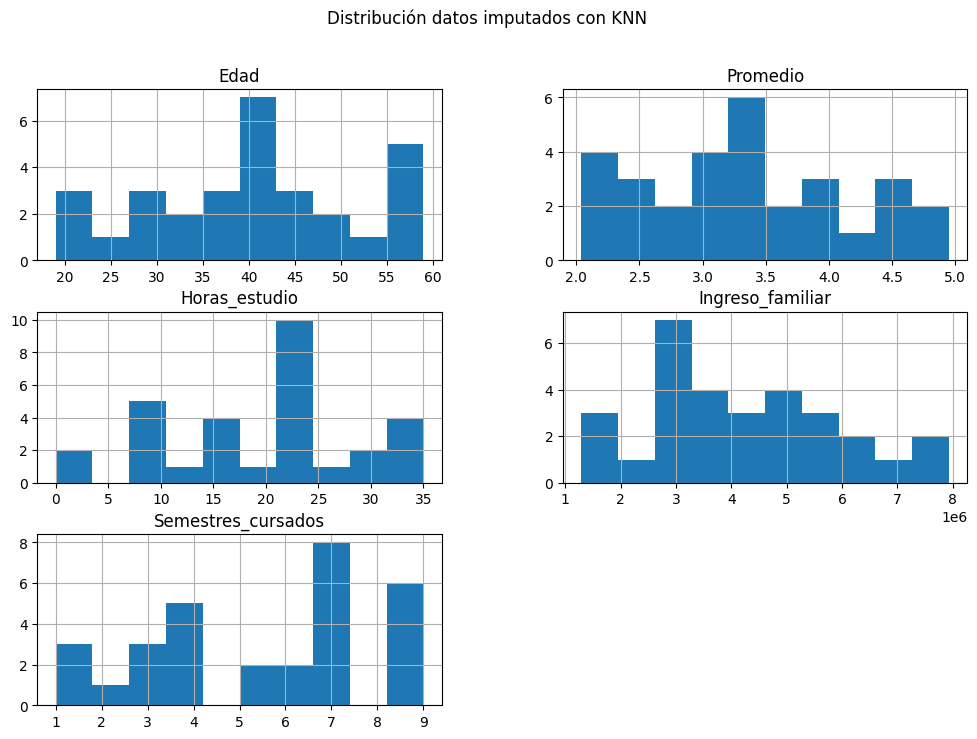

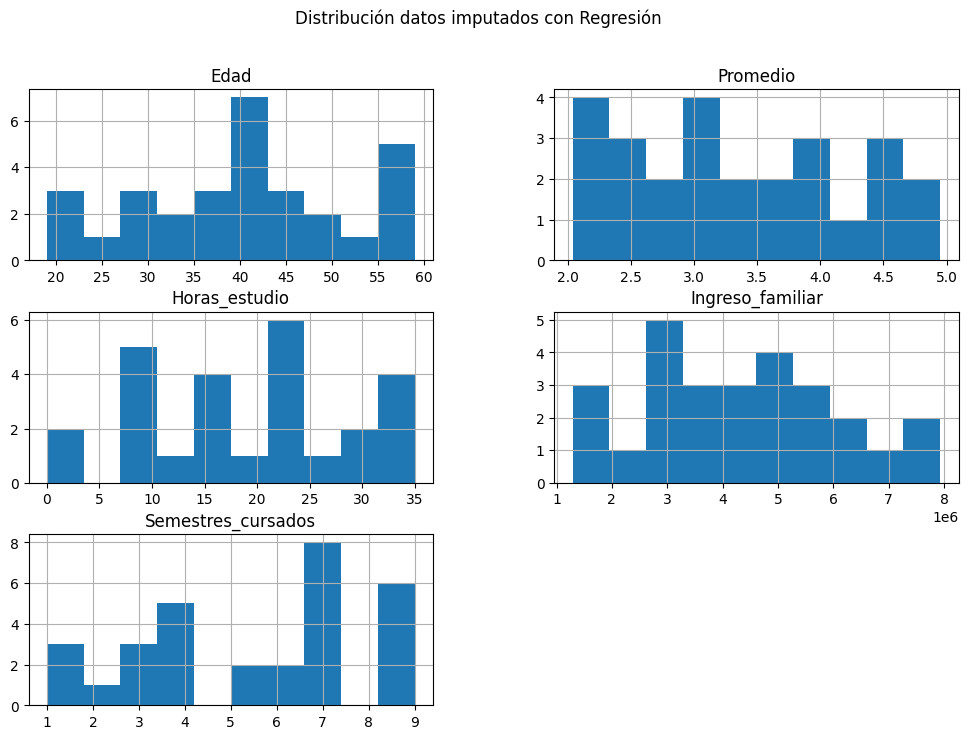

In [34]:
# Original (con NaN)
graficar_distribuciones(df, "Distribución datos originales")

# KNN
graficar_distribuciones(df_knn_imputed, "Distribución datos imputados con KNN")

# Regresión
graficar_distribuciones(df_reg, "Distribución datos imputados con Regresión")

No consideron que en ninguno de los casos se haya afectado drasticamente la distribución de los datos, sin embargo puede notarse que KNN mueve un poco los datos hacia una tendencia central, esto puede deberse a que utiliza observaciones cercanas para estimar los valores, por otro lado los valores de regresión  se ven más suavizados y dispersos.

## <span style="color:#2F749F;"><strong>Ejercicio 6. Imputación con LOCF y NOCB</strong></span>

1. Crea el DataFrame base ejecutando el siguiente código:

    ```python
        import pandas as pd
        import numpy as np

        np.random.seed(42)

        n = 30

        df = pd.DataFrame({
            'Fecha': pd.date_range(start='2023-01-01', periods=n, freq='D'),
            'Ventas': np.round(np.random.uniform(100, 500, n), 2),
            'Inventario': np.random.randint(10, 100, n),
            'Clientes': np.random.randint(1, 50, n)
        })

        # Introducción de valores faltantes
        df.loc[[3, 4, 5, 12, 13], 'Ventas'] = np.nan
        df.loc[[7, 8, 20], 'Inventario'] = np.nan
        df.loc[[1, 2, 18, 19], 'Clientes'] = np.nan
        df = df.sort_values('Fecha').reset_index(drop=True)

2. Al analizar el DataFrame `df`:
   - ¿Qué variables presentan datos faltantes consecutivos?
   - ¿Por qué este tipo de patrón es relevante en series temporales?
   - ¿Qué implicaciones tiene el orden de los datos para este tipo de imputación?
3. Realiza la imputación de valores faltantes utilizando LOCF y NOCB
4. ¿Cuál método consideras más apropiado para este caso y por qué?